# Pattern Recognition mit Dynamic Time Warping

*MSC WI - DIFA - HS24/25*

**Studierende:**
- Yann Lüthi
- Pascal Knecht

---

**Inhaltsverzeichnis:**

1. [Einleitung](#1)
2. [Implementierungsgrundlagen](#2)
    1. [Imports](#2-1)
    2. [Hilfsfunktionen](#2-2)
3. [Datenbezug und -aufbereitung](#3)
    1. [Datengenerierung](#3-1)
    2. [Datenbezug von Yahoo Finance](#3-2)
4. [Daten persistieren und wieder laden](#4)
5. [Basis-Daten visualisieren](#5)
6. [Daten aufbereiten](#6)
    1. [Daten glätten](#6-1)
    2. [Erste Ableitung berechnen](#6-2)
    3. [Daten standardisieren](#6-3)

## 1. Einleitung <a id="1"></a>
In diesem Jupyter-Notebook wird die Implementierung von Dynamic Time Warping (DTW) beschrieben und mit entsprechendem Code aufgezeigt. Die theoretischen Details dazu, mitsamt der Projektplanung sind in der entsprechenden, begleitenden PDF-Datei einsehbar.

## 2. Implementierungsgrundlagen <a id="2"></a>
Im nachfolgenden Kapitel werden die grundlegenden Imports und Hilfsfunktionen umgesetzt und kurz beschrieben, die im weiteren Verlauf des Jupyter-Notebooks eingesetzt werden. 

### 2.1 Imports <a id="2-1"></a>
Für die Umsetzung und Verifikation der Mustererkennung mit DTW sollen soweit möglich, etablierte Libraries und Funktionen zum Einsatz kommen. Diesbezüglich werden folgende Libraries eingesetzt:

In [98]:
import numpy as np                  # library for numerical calculations
import matplotlib.pyplot as plt     # library for plotting
import pandas as pd                 # library for data manipulation
import yfinance as yf               # library for downloading financial data from Yahoo Finance
import time                         # library for time-related functions
import pickle                       # library for saving and loading data (with extended support for python objects)
import scipy                        # library for scientific computing

### 2.2 Hilfsfunktionen <a id="2-2"></a>
In diesem Kapitel wird eine im Buch beschriebene Hilfsfunktion definiert, die im vorliegenden Notebook verwendet wird.

Eine zentrale Funktion ist die *rw*-Funktion (Rolling Window), die aus Anhang 1 (S. 38f) von Kapitel 2 der bereitgestellten Literatur *'Technical Analysis for Algorithmic Pattern Recognition'* von Tsinaslanidis & Zapranis (2016) stammt. Sie dient dazu, aus einer Reihe *ys* von Werten (im vorliegenden Anwendungsfall primär den akkumulierten Distanzen im Rahmen von DDTW zwischen zwei Zeitreihen) die lokalen "Peaks" und "Bottoms" innerhalb eines Fensters der Grösse *w* zu identifizieren. Über den Parameter *pflag* kann festgelegt werden, ob die x- und y-Koordinaten der Peaks und Bottoms nur ausgegeben (*pflag=False*) oder zusätzlich geplottet werden sollen (*pflag=True*). Zusätzlich kann der Titel des Plots über den Parameter *customTitle* angepasst werden.

Die Funktion wurde anhand des im Buch abgedruckten Pseudocodes in Python implementiert und hinsichtlich der Grafikausgabe leicht erweitert.

In [68]:
# rw function (according to appendix 1 of chapter 2)
def rw(ys, w, pflag=False, customTitle=None):
    """
    Function to detect regional peaks and bottoms in a time series within window w.

    Args:
        ys: time series data
        w: window size
        pflag: plot flag (default is False)
        customTitle: custom title for the plot (default is None)

    Returns:
        peaks: peaks coordinates
        bottoms: bottoms coordinates
    """

    l = len(ys)

    if l < (2 * w + 1): # check if the length of the time series is less than 2*w+1
        raise ValueError('The length of the time series is less than 2*w+1 and therefore not sufficient for the rw analysis.')

    peaks_bottoms = np.zeros((l, 2)) # 1st column for peaks, 2nd column for bottoms
    for i in range(w, l - w): 
        if ys[i] > max(ys[i - w:i]) and ys[i] > max(ys[i + 1:i + w]): # peak found -> set 1 to the 1st column
            peaks_bottoms[i, 0] = 1 
        if ys[i] < min(ys[i - w:i]) and ys[i] < min(ys[i + 1:i + w]): # bottom found -> set 1 to the 2nd column
            peaks_bottoms[i, 1] = 1

    p_indx = np.where(peaks_bottoms[:, 0] == 1)[0] # indices of peaks
    b_indx = np.where(peaks_bottoms[:, 1] == 1)[0] # indices of bottoms

    peaks = np.array([ [ys[i],i] for i in p_indx ]) # build the coordinates of peaks
    bottoms = np.array([ [ys[i],i] for i in b_indx ]) # build the coordinates of bottoms

    if pflag: # plot the results
        plt.figure(figsize=(8, 4))
        plt.plot(ys, label='Price series', color='lightgray')
        if len(peaks): plt.plot(peaks[:, 1], peaks[:, 0], 'ro', label='Peaks') # plot red circles for peaks
        if len(bottoms): plt.plot(bottoms[:, 1], bottoms[:, 0], 'r*', label='Bottoms') # plot red stars for bottoms
        plt.title(customTitle if customTitle else 'Peaks and Bottoms')
        plt.legend()

    return peaks, bottoms

## 3. Datenbezug <a id="3"></a>
In diesem Kapitel wird erläutert, wie die Daten für die nachfolgenden Analysen beschafft und vorbereitet werden. 

Für den Datenbezug wird zunächst der zu betrachtende Datumsbereich definiert:

In [69]:
START_DATE = '2009-11-30'
END_DATE = '2024-11-30'

dates = np.arange(START_DATE, END_DATE, dtype='datetime64[D]')

### 3.1 Datengenerierung <a id="3-1"></a>
Zur Überprüfung der Funktionalität der in diesem Notebook implementierten Scripts wurden zunächst zufällig generierte Zeitreihen verwendet. Dies ermöglichte eine iterative Analyse, um die relevanten Parameter der Zeitreihen zu identifizieren und darauf basierend geeignete Datenquellen mit realen Inhalten auszuwählen. Die generierten Daten dienen ausschliesslich als Mock-Daten für die Entwicklung und werden ausdrücklich nicht für die abschliessenden Auswertungen, Analysen oder Diskussionen verwendet.

In [ ]:
NUM_ASSETS = 3         # number of assets to generate
RANDOM_SEED = 42        # random seed for reproducibility

np.random.seed(RANDOM_SEED)

assets = [] # array of assets

for i in range(NUM_ASSETS):
    # generate random price series and caluculate dependent data
    prices = np.cumsum(np.random.randn(len(dates)) * 2) + 100

    # add generated information/asset data to assets array
    assets.append({
        'ticker': f'ASSET{i+1}',
        'type': 'mock',
        'prices': prices
    })

### 3.2 Datenbezug von Yahoo Finance <a id="3-2"></a>
Für die vorliegende Arbeit erwies sich der Datenbezug von Yahoo Finance als die geeignetste Wahl. Im folgenden Code-Ausschnitt wird gezeigt, wie die Daten aus dieser Quelle abgerufen werden. Zu Beginn wird definiert, welche Ticker berücksichtigt werden sollen. Dabei werden unterschiedliche Assettypen abgerufen, die im Feld 'type' der Asset-Objekte hinterlegt werden.

In [77]:
queriedAssetTypes = [
    {
        'type': 'tech',
        'tickers': ['AAPL', 'MSFT', 'GOOGL']        # Apple, Microsoft, Google
    },
    {
        'type': 'consumer_staples',
        'tickers': ['NESN.SW', 'PG', 'UL']          # Nestle, Procter & Gamble, Unilever (note: international tickers)
    },
    {
        'type': 'industrial',
        'tickers': ['ABBN.SW', 'SIEGY', 'GE']       # ABB, Siemens, General Electric (note: international tickers)
    },
    {
        'type': 'precious_metals',                  # future contracts, as Yahoo Finance does not provide spot prices
        'tickers': ['GC=F', 'SI=F', 'PL=F']         # Gold, Silver, Platinum
    },
    {
        'type': 'market_indexes',
        'tickers': ['^SSMI', '^GDAXI', '^GSPC']     # Swiss Market Index, DAX, S&P 500
    }
]

assets = [] # array of assets

for queriedAssetType in queriedAssetTypes:
    type = queriedAssetType['type']
    for ticker in queriedAssetType['tickers']:
        # download asset data
        asset = yf.Ticker(ticker)
        assetHistory = asset.history(interval='1d',start=START_DATE,end=END_DATE)
        

        # fill in missing data (e.g. weekends/holidays) by using the last available price
        lastValue = assetHistory['Open'].iloc[0]
        dataPointer = 0
        index = assetHistory.index
        prices = []
        for date in dates:
            if dataPointer < len(index) and index[dataPointer].strftime("%Y-%m-%d") == str(date):
                prices.append(assetHistory['Close'].iloc[dataPointer])
                lastValue=assetHistory['Close'].iloc[dataPointer]
                dataPointer += 1
            else:
                prices.append(lastValue)

        # add asset data to assets array
        assets.append({
            'ticker': ticker,
            'type': type,
            'prices': prices
        })

        print(f'Successfully fetched data for {ticker} ({type})')
        time.sleep(1) # sleep for 1 second to avoid being blocked by Yahoo Finance

    

Successfully fetched data for AAPL (tech)
Successfully fetched data for MSFT (tech)
Successfully fetched data for GOOGL (tech)
Successfully fetched data for NESN.SW (consumer_staples)
Successfully fetched data for PG (consumer_staples)
Successfully fetched data for UL (consumer_staples)
Successfully fetched data for ABBN.SW (industrial)
Successfully fetched data for SIEGY (industrial)
Successfully fetched data for GE (industrial)
Successfully fetched data for GC=F (precious_metals)
Successfully fetched data for SI=F (precious_metals)
Successfully fetched data for PL=F (precious_metals)
Successfully fetched data for ^SSMI (market_indexes)
Successfully fetched data for ^GDAXI (market_indexes)
Successfully fetched data for ^GSPC (market_indexes)


## 4. Daten persistieren und wieder laden <a id="4"></a>
Um zu vermeiden, dass die in Kapitel 3 bezogenen oder generierten Daten bei jeder Ausführung erneut von Yahoo Finance geladen oder neu erstellt werden müssen, wird in diesem Kapitel beschrieben, wie diese Daten gespeichert (persistiert) und bei Bedarf wieder geladen werden können. Dies ist besonders bei den Yahoo Finance-Daten sinnvoll, da sie sich für denselben Zeitraum in der Regel nicht ändern und der erneute Abruf zusätzliche Zeit erfordert.

Da die Asset-Objekte NumPy-Arrays enthalten, die sich nicht direkt serialisieren lassen, beispielsweise zur Ausgabe in JSON-Dateien, wird für diesen Zweck Pickle verwendet. Dies vermeidet die Notwendigkeit, eine zusätzliche Wrapper- oder Übersetzungsfunktion zu implementieren, die keinen wesentlichen Mehrwert bietet, abgesehen davon, dass der Output als JSON-Objekt vorliegen würde.

(Hinweis: Diese Code-Abschnitte können auch nach den folgenden Schritten problemlos verwendet werden, um spätere Zwischenstände zu speichern oder wieder zu laden.)

In [71]:
ASSET_PATH = 'data/assets.pkl'

with open(ASSET_PATH, 'wb') as f:
    pickle.dump(assets, f)

print(f'Successfully saved data to {ASSET_PATH}')

Successfully saved data to data/assets.pkl


In [72]:
ASSET_PATH = 'data/assets.pkl'

with open(ASSET_PATH, 'rb') as f:
    assets = pickle.load(f)

print(f'Successfully loaded {len(assets)} assets from {ASSET_PATH}')

Successfully loaded 15 assets from data/assets.pkl


## 5. Basis-Daten visualisieren <a id="5"></a>
Die bezogenen Zeitreihen werden in diesem Kapitel visualisiert, um sicherzustellen, dass sie vollständig sind und in erwartetem Rahmen ausfallen. Dabei können mögliche Datenlücken oder Abweichungen von den erwarteten Mustern erkannt, analysiert und gegebenenfalls behoben werden. 

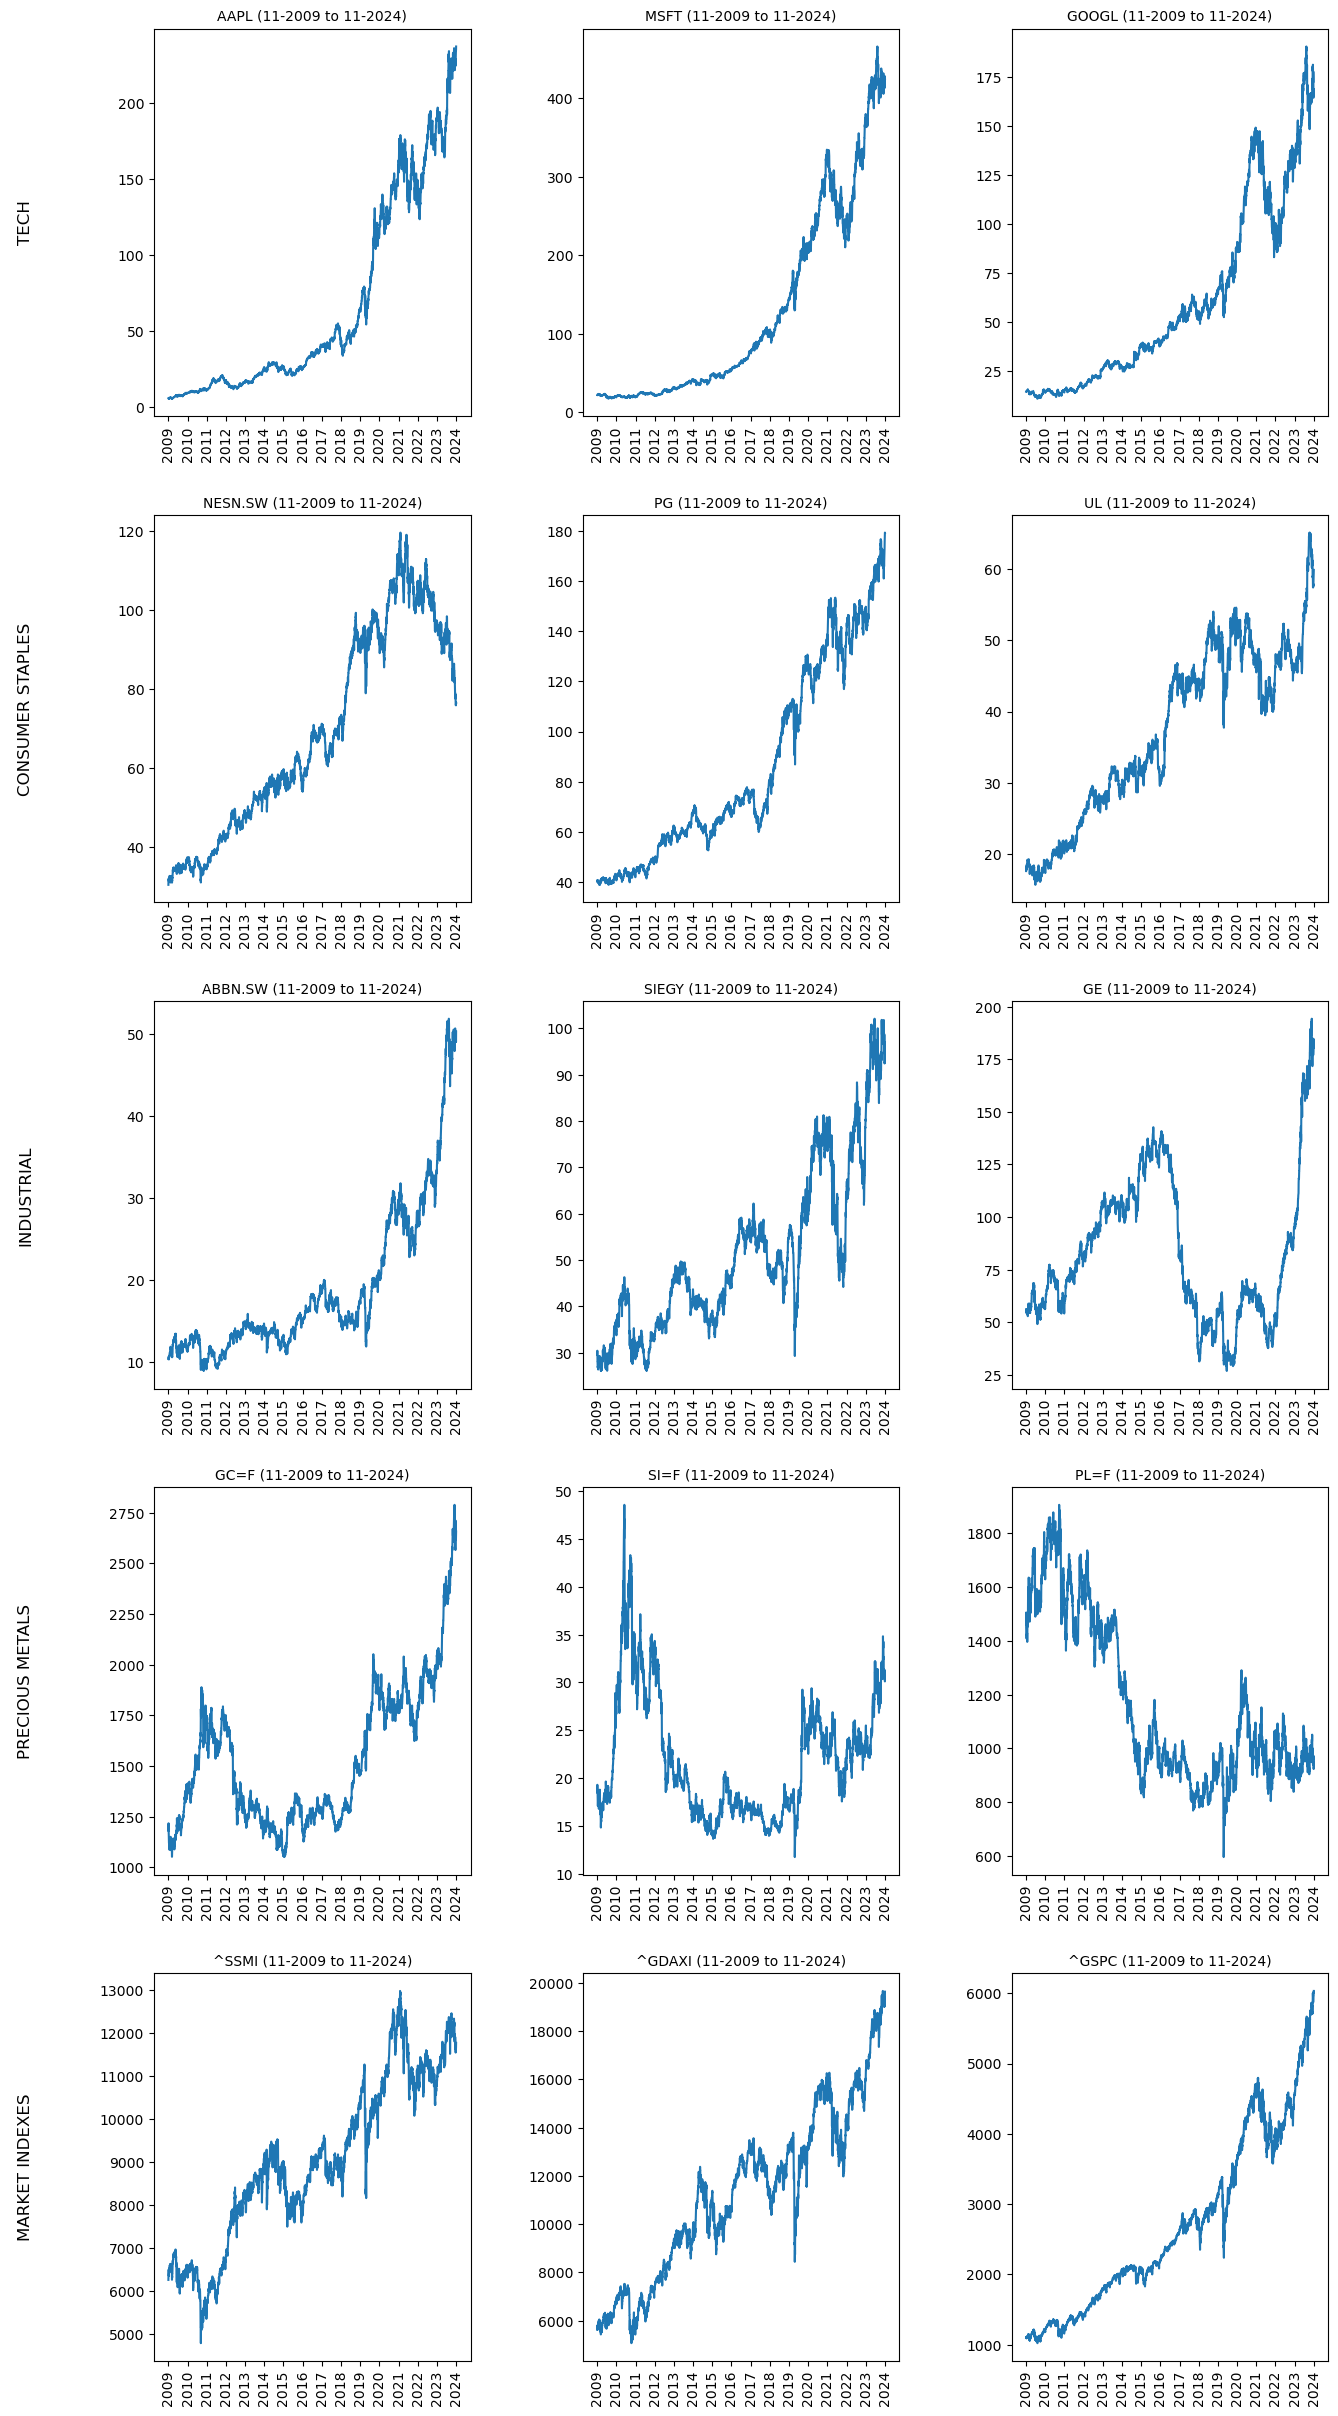

In [97]:
# group assets by type for grouped plotting
grouped_assets = {}
for asset in assets:
    if asset['type'] not in grouped_assets:
        grouped_assets[asset['type']] = []
    grouped_assets[asset['type']].append(asset)

# prepare plot
num_rows = len(grouped_assets)
fig, axs = plt.subplots(num_rows, 3 + 1, figsize=(15, num_rows * 5), gridspec_kw={'width_ratios': [0.1] + [1] * 3})
fig.tight_layout(pad=5)

for i, (asset_type, group) in enumerate(grouped_assets.items()): # for each group of assets
    # add group name on the left of the asset plots
    axs[i, 0].text(0.5, 0.5, asset_type.upper().replace('_',' '), va='center', ha='center', fontsize=12, rotation=90)
    axs[i, 0].axis('off') # disable axis for group name
    
    for j, asset in enumerate(group): # for each asset in the group
        ax = axs[i, j + 1]
        
        # plot asset prices
        ax.plot(asset['prices'])
        
        # add x-axis labels for each year
        date_range = pd.date_range(start=START_DATE, periods=len(asset['prices']))
        ticks = np.linspace(0, len(asset['prices']) - 1, 16, dtype=int)
        ax.set_xticks(ticks)
        ax.set_xticklabels(date_range[ticks].strftime('%Y'), rotation=90)
        
        # set title for the asset plot 
        ax.set_title(f"{asset['ticker']} (11-2009 to 11-2024)", fontsize=10)

plt.show()

## 6. Daten aufbereiten <a id="6"></a>
Die vorgegebene Literatur (*'Technical Analysis for Algorithmic Pattern Recognition'* von Tsinaslanidis & Zapranis (2016)) beschreibt mehrere Schritte zur Datenaufbereitung, die für eine effektive Mustererkennung mittels DTW, konkret mittels subsequence DDTW, erforderlich sind. Diese Schritte müssen spezifisch auf die Referenz- und Vergleichssequenzen angewendet werden. Daher erfolgt in diesem Schritt keine vollständige Datenaufbereitung. Stattdessen werden Funktionen bereitgestellt, die eine gezielte und flexible Anwendung der Aufbereitung ermöglichen. (Eine globale Bearbeitung der gesamten Zeitreihe anstelle der individuellen Teilsequenzen könnte insbesondere bei Prozessen wie Glättung oder Skalierung zu unerwünschten Verzerrungen führen.)

Um die Funktionalität der einzelnen Aufbereitungsschritte zu prüfen und ihre Auswirkungen aufzuzeigen, werden diese exemplarisch anhand einer vollständigen Zeitreihe eines Assets demonstriert. Dies ermöglicht eine Visualisierung und eine gezielte Analyse der Effekte, die jeder Aufbereitungsschritt auf die Zeitreihe hat.

### 6.1. Daten glätten <a id="6-1"></a>
Angelehnt an das Beispiel in der Literatur wird die Zeitreihe mit dem Savitzky-Golay-Algorithmus geglättet, um das Rauschen der Daten zu reduzieren, ohne dabei wesentliche Muster zu verfälschen. Für die Glättung werden, wie im Beispiel der Literatur, in einer ersten Phase ein kubischer Polynomgrad (3) und eine Fenstergrösse von 21 verwendet. Diese Parameter sollen eine Balance zwischen Rauschunterdrückung und dem Erhalt lokaler Muster bilden. Durch die Glättung werden die im nächsten Schritt berechneten Ableitungen stabiler und weniger anfällig für Ausreisser. Dabei ist darauf zu achten, dass die Glättung nicht zu stark gewählt wird, um relevante Details der Zeitreihe zu erhalten.

Dieser Algorithmus ist unter dem Namen *savgol_filter* in der *SciPy*-Library verfügbar und ermöglicht eine effiziente und einfache Implementierung der Savitzky-Golay-Glättung. Der nachfolgende, einfache Wrapper basiert auf dieser etablierten Implementierung und nutzt ihre Flexibilität zur Anpassung von Parametern wie Fenstergrösse und Polynomgrad.

In [110]:
def smoothTimeSeries(timeSeries, polyOrder=3, windowSize=21):
    """
    Function to smooth a time series using Savitzky-Golay filter.

    Args:
        timeSeries: time series data
        polyOrder: polynomial order (default is 3)
        windowSize: window size (default is 21)

    Returns:
        smoothedTimeSeries: smoothed time series data
    """
    return scipy.signal.savgol_filter(timeSeries, windowSize, polyOrder)

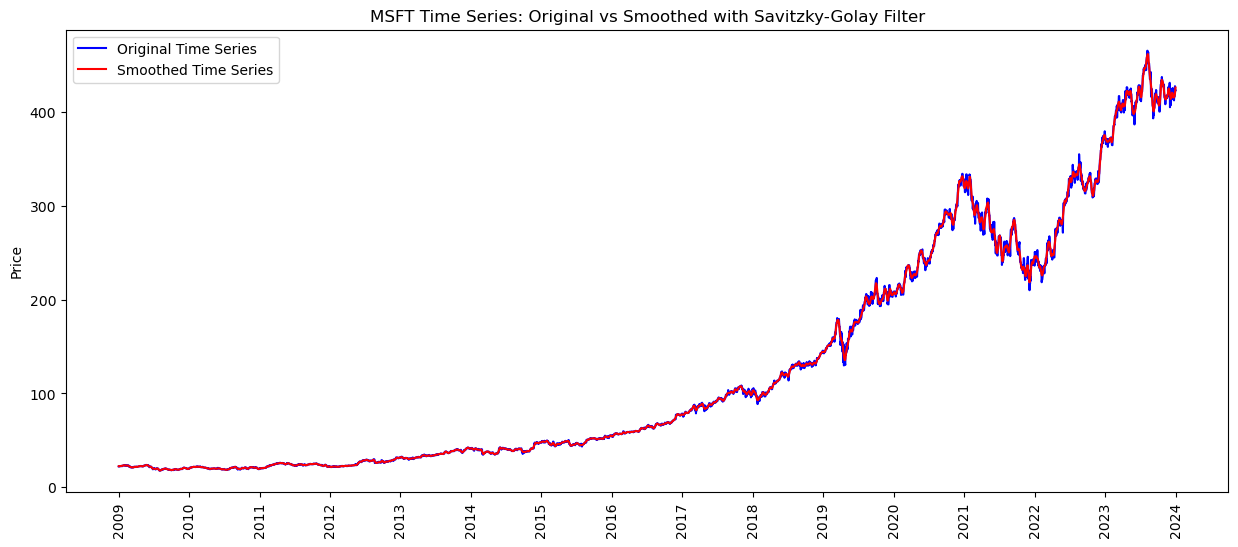

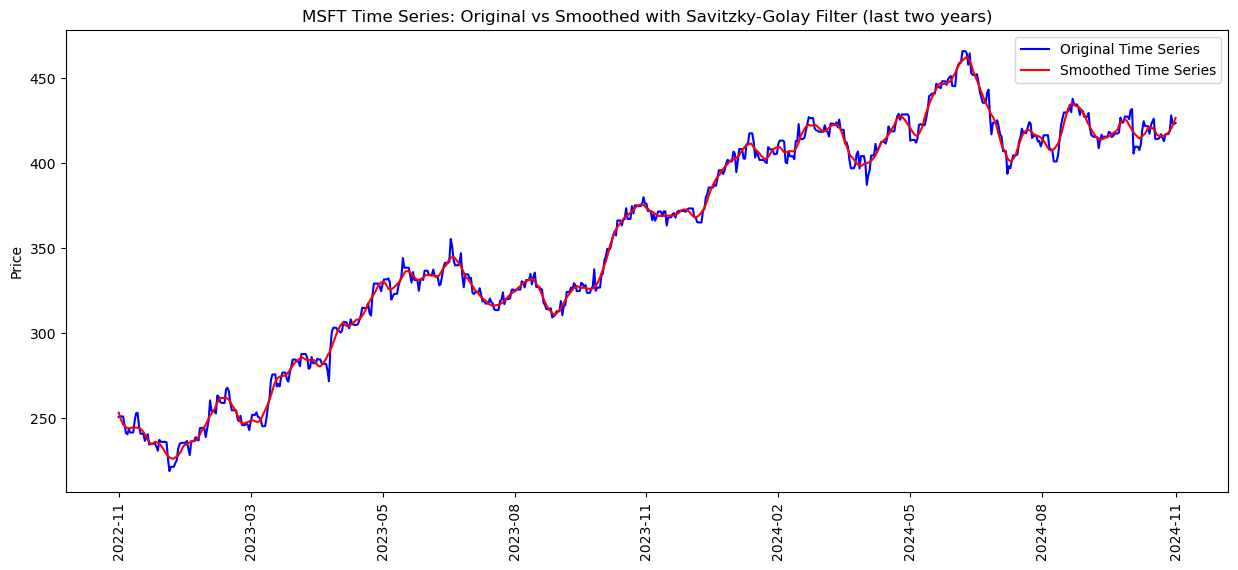

In [123]:
# Smoothing demonstration on Microsoft stock data
msft_asset = next(asset for asset in assets if asset['ticker'] == 'MSFT')

# Original time series
original_series = msft_asset['prices']

# Smoothed time series
smoothed_series = smoothTimeSeries(original_series)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(original_series, label='Original Time Series', color='blue')
plt.plot(smoothed_series, label='Smoothed Time Series', color='red')
plt.title('MSFT Time Series: Original vs Smoothed with Savitzky-Golay Filter')
date_range = pd.date_range(start=START_DATE, periods=len(asset['prices']))
ticks = np.linspace(0, len(asset['prices']) - 1, 16, dtype=int)
plt.xticks(ticks, date_range[ticks].strftime('%Y'), rotation=90)
plt.ylabel('Price')
plt.legend()
plt.show()

# Plotting the last two years of data to show the smoothing effect "zoomed in"
num_days_shown = 2 * 365
original_series_shortened = original_series[-num_days_shown:]
smoothed_series_shortened = smoothTimeSeries(original_series_shortened)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(original_series_shortened, label='Original Time Series', color='blue')
plt.plot(smoothed_series_shortened, label='Smoothed Time Series', color='red')
plt.title('MSFT Time Series: Original vs Smoothed with Savitzky-Golay Filter (last two years)')
date_range_shortened = pd.date_range(start=pd.Timestamp(END_DATE) - pd.DateOffset(years=2), periods=num_days_shown)
ticks_shortened = np.linspace(0, num_days_shown - 1, 9, dtype=int)
plt.xticks(ticks_shortened, date_range_shortened[ticks_shortened].strftime('%Y-%m'), rotation=90)
plt.ylabel('Price')
plt.legend()
plt.show()

### 6.2. Erste Ableitung berechnen <a id="6-2"></a>
In diesem Schritt wird anschliessend die erste Ableitung der geglätteten Zeitserien berechnet, um die Dynamik der Daten besser zu erfassen und Unterschiede im Preisniveau auszugleichen. Die Berechnung erfolgt dabei, angelehnt an die vorgegebene Literatur, mit der Methode von Keogh und Pazzani (2001) mittels zentraler Differenzen. Für jeden Punkt wird die Differenz zwischen den benachbarten Werten berechnet und durch zwei geteilt. Dieser Ansatz ist robuster gegenüber Ausreissern und liefert stabile Ergebnisse, die sich besonders gut für die weitere Analyse mit subsequence DDTW eignen. Diese Methode erfordert keine zusätzlichen Parameter und basiert ausschliesslich auf den Werten der geglätteten Zeitreihe, wodurch sie direkt und unkompliziert anwendbar ist.

In [133]:
def calculateDerivatives(timeSeries):
    """
    Function to calculate the first derivatives of a time series.
    
    Args:
        timeSeries: time series data
    
    returns:
        derivatives: series of first derivatives of the time series
    """
    
    derivatives = np.zeros_like(timeSeries) # initialize the derivatives array
    for i in range(1, len(timeSeries) - 1): 
        derivatives[i] = ((timeSeries[i]-timeSeries[i-1]) + 0.5*(timeSeries[i+1]-timeSeries[i-1])) / 2 # according to formula (9.11) in the book
    
    return derivatives
    

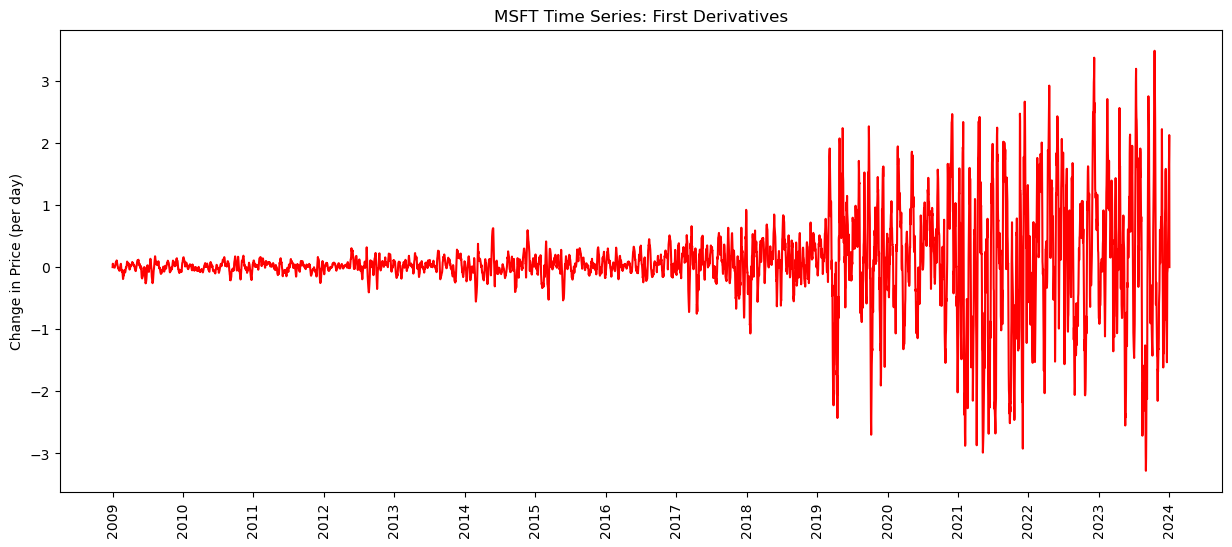

In [142]:
# Derivative demonstration on Microsoft stock data

# First derivatives of the smoothed time series
first_derivatives = calculateDerivatives(smoothed_series)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(first_derivatives, color='red')
plt.title('MSFT Time Series: First Derivatives')
date_range = pd.date_range(start=START_DATE, periods=len(asset['prices']))
ticks = np.linspace(0, len(asset['prices']) - 1, 16, dtype=int)
plt.xticks(ticks, date_range[ticks].strftime('%Y'), rotation=90)
plt.ylabel('Change in Price (per day)')
plt.show()


### 6.3. Daten standardisieren <a id="6-3"></a>
Der letzte Schritt zur Aufbereitung der Daten besteht darin, diese zu standardisieren. Ziel der Standardisierung ist es, die Werte der Zeitreihe auf einen einheitlichen Massstab zu transformieren, um Verzerrungen durch unterschiedliche Grössenordnungen oder Einheiten zu vermeiden. Dadurch wird die Vergleichbarkeit zwischen der Referenz- und der Vergleichssequenz erheblich verbessert.

In der vorgegebenen Literatur wird hierfür die weitverbreitete Z-Transformation angewendet (auch wenn sie nicht explizit erwähnt wird). Diese Transformation passt die Werte so an, dass die Zeitreihe einen Mittelwert von 0 und eine Standardabweichung von 1 aufweist. Eine Funktion zur Durchführung der Z-Transformation wird im Folgenden implementiert und demonstriert.

In [146]:
def standardizeData(timeSeries):
    """
    Function to standardize a time series.
    
    Args:
        timeSeries: time series data
    
    returns:
        standardizedTimeSeries: standardized time series data
    """
    timeSeries = np.array(timeSeries) # convert to numpy array if not already
    return (timeSeries - np.mean(timeSeries)) / np.std(timeSeries) 

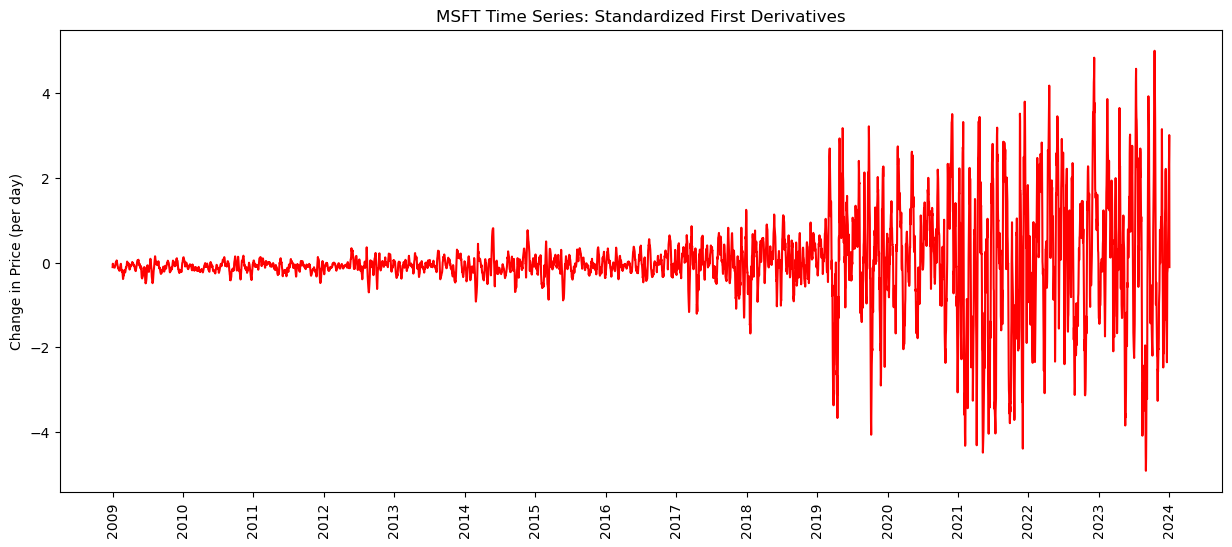

Mean of first derivatives: 0.0734359121614568
Standard deviation of first derivatives: 0.682278456239572
Mean of standardized first derivatives: 0.0
Standard deviation of standardized first derivatives: 1.0


In [149]:
# Standardization demonstration on Microsoft stock data

# Standardized first derivatives
standardized_first_derivatives = standardizeData(first_derivatives)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(standardized_first_derivatives, color='red')
plt.title('MSFT Time Series: Standardized First Derivatives')
date_range = pd.date_range(start=START_DATE, periods=len(asset['prices']))
ticks = np.linspace(0, len(asset['prices']) - 1, 16, dtype=int)
plt.xticks(ticks, date_range[ticks].strftime('%Y'), rotation=90)
plt.ylabel('Change in Price (per day)')
plt.show()


# Calculate the mean and standard deviation of the first derivatives and standardized first derivatives
print(f'Mean of first derivatives: {np.mean(first_derivatives)}')
print(f'Standard deviation of first derivatives: {np.std(first_derivatives)}')

print(f'Mean of standardized first derivatives: {np.mean(standardized_first_derivatives)}')
print(f'Standard deviation of standardized first derivatives: {np.std(standardized_first_derivatives)}')